# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_eM_fold,max_cM_fold,T_eM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
20,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
153,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
286,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
419,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
552,0.0,0.01,50000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.0000,20.0000,0.180527,0.060789,0.000000,9.876317e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41205226,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,5.302957e+06,783.724370,0.160228,0.093772,4.263644,0.0,20.0,20.0000,-8.7776,0.027191,1.122812,0.000533,6.028162e+06,3.349485,2.651569,0.000090,0.000392
41205359,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,5.302920e+06,963.710828,0.193273,0.114833,4.272375,0.0,20.0,20.0000,-5.1360,0.027191,1.122806,0.000659,6.028195e+06,3.349485,2.651569,0.000108,0.000482
41205492,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.302317e+06,3528.295515,0.471683,0.303354,4.217698,0.0,20.0,20.0000,-9.4800,0.027186,1.122714,0.002410,6.028750e+06,3.349485,2.651569,0.000410,0.001764
41205625,0.1,0.01,100000000.0,1000000.0,10000000.0,3000.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,5.287471e+06,58227.795937,1.542615,0.535775,2.426244,0.0,20.0,5.1264,-11.3440,0.027066,1.120395,0.195402,6.042383e+06,3.349485,2.651569,0.007833,0.029114


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Threshold"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

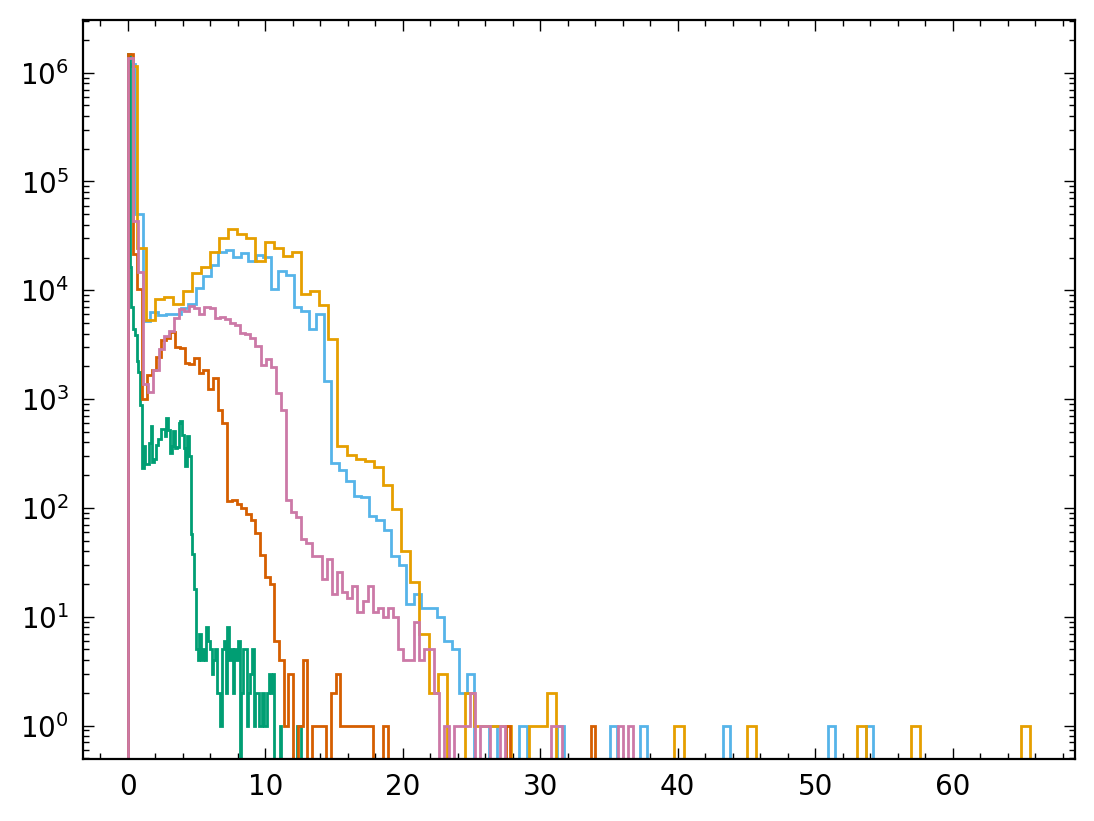

In [4]:
# Inspect distribution of observables
sel = 'peff_protection'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,-26.795884,1.681457,1.062424,0.660597
1,-6.698971,3.212137,1.055515,0.767523
2,0.700124,0.210929,1.162174,0.128207
3,0.717337,0.280461,1.341999,0.179550
4,0.735609,0.341194,1.457485,0.238624
...,...,...,...,...
100,2.677607,4.729134,1.638527,0.514291
101,2.813581,5.058417,1.663644,0.557237
102,3.349485,0.026993,1.117700,0.106464
103,5.359177,0.143154,1.114857,0.152336


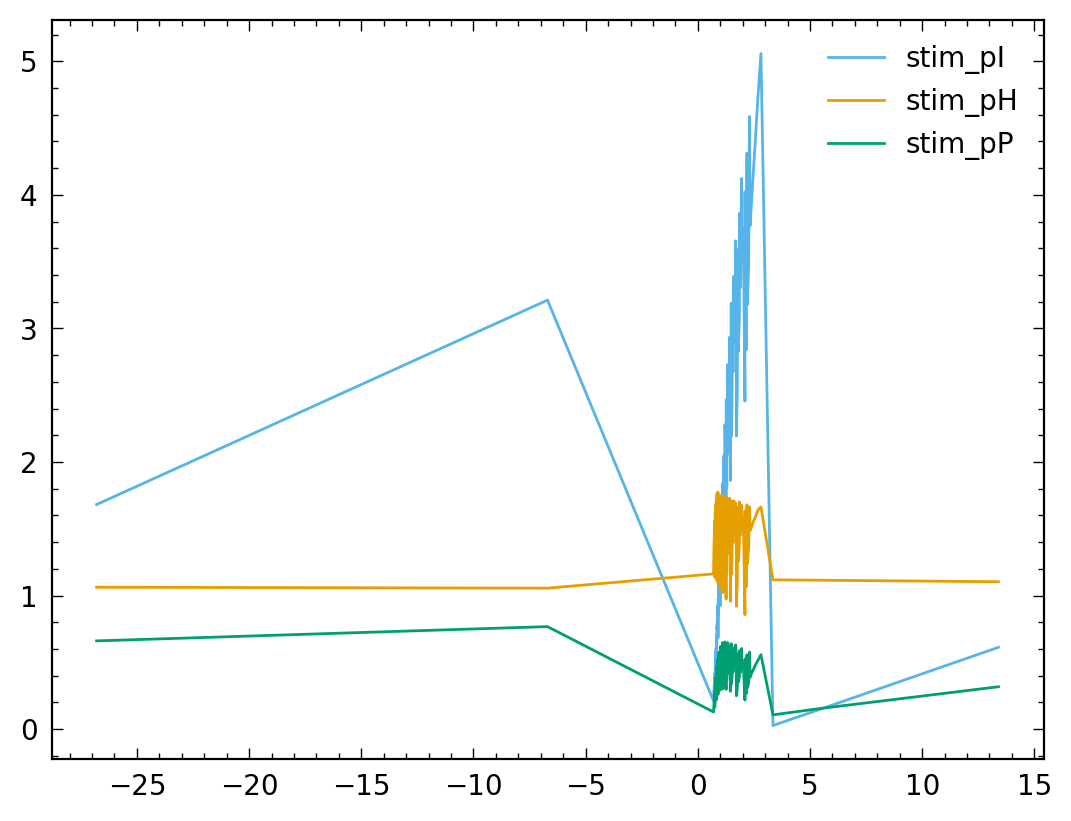

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 8
fevals: 12
fevals: 14
fevals: 53


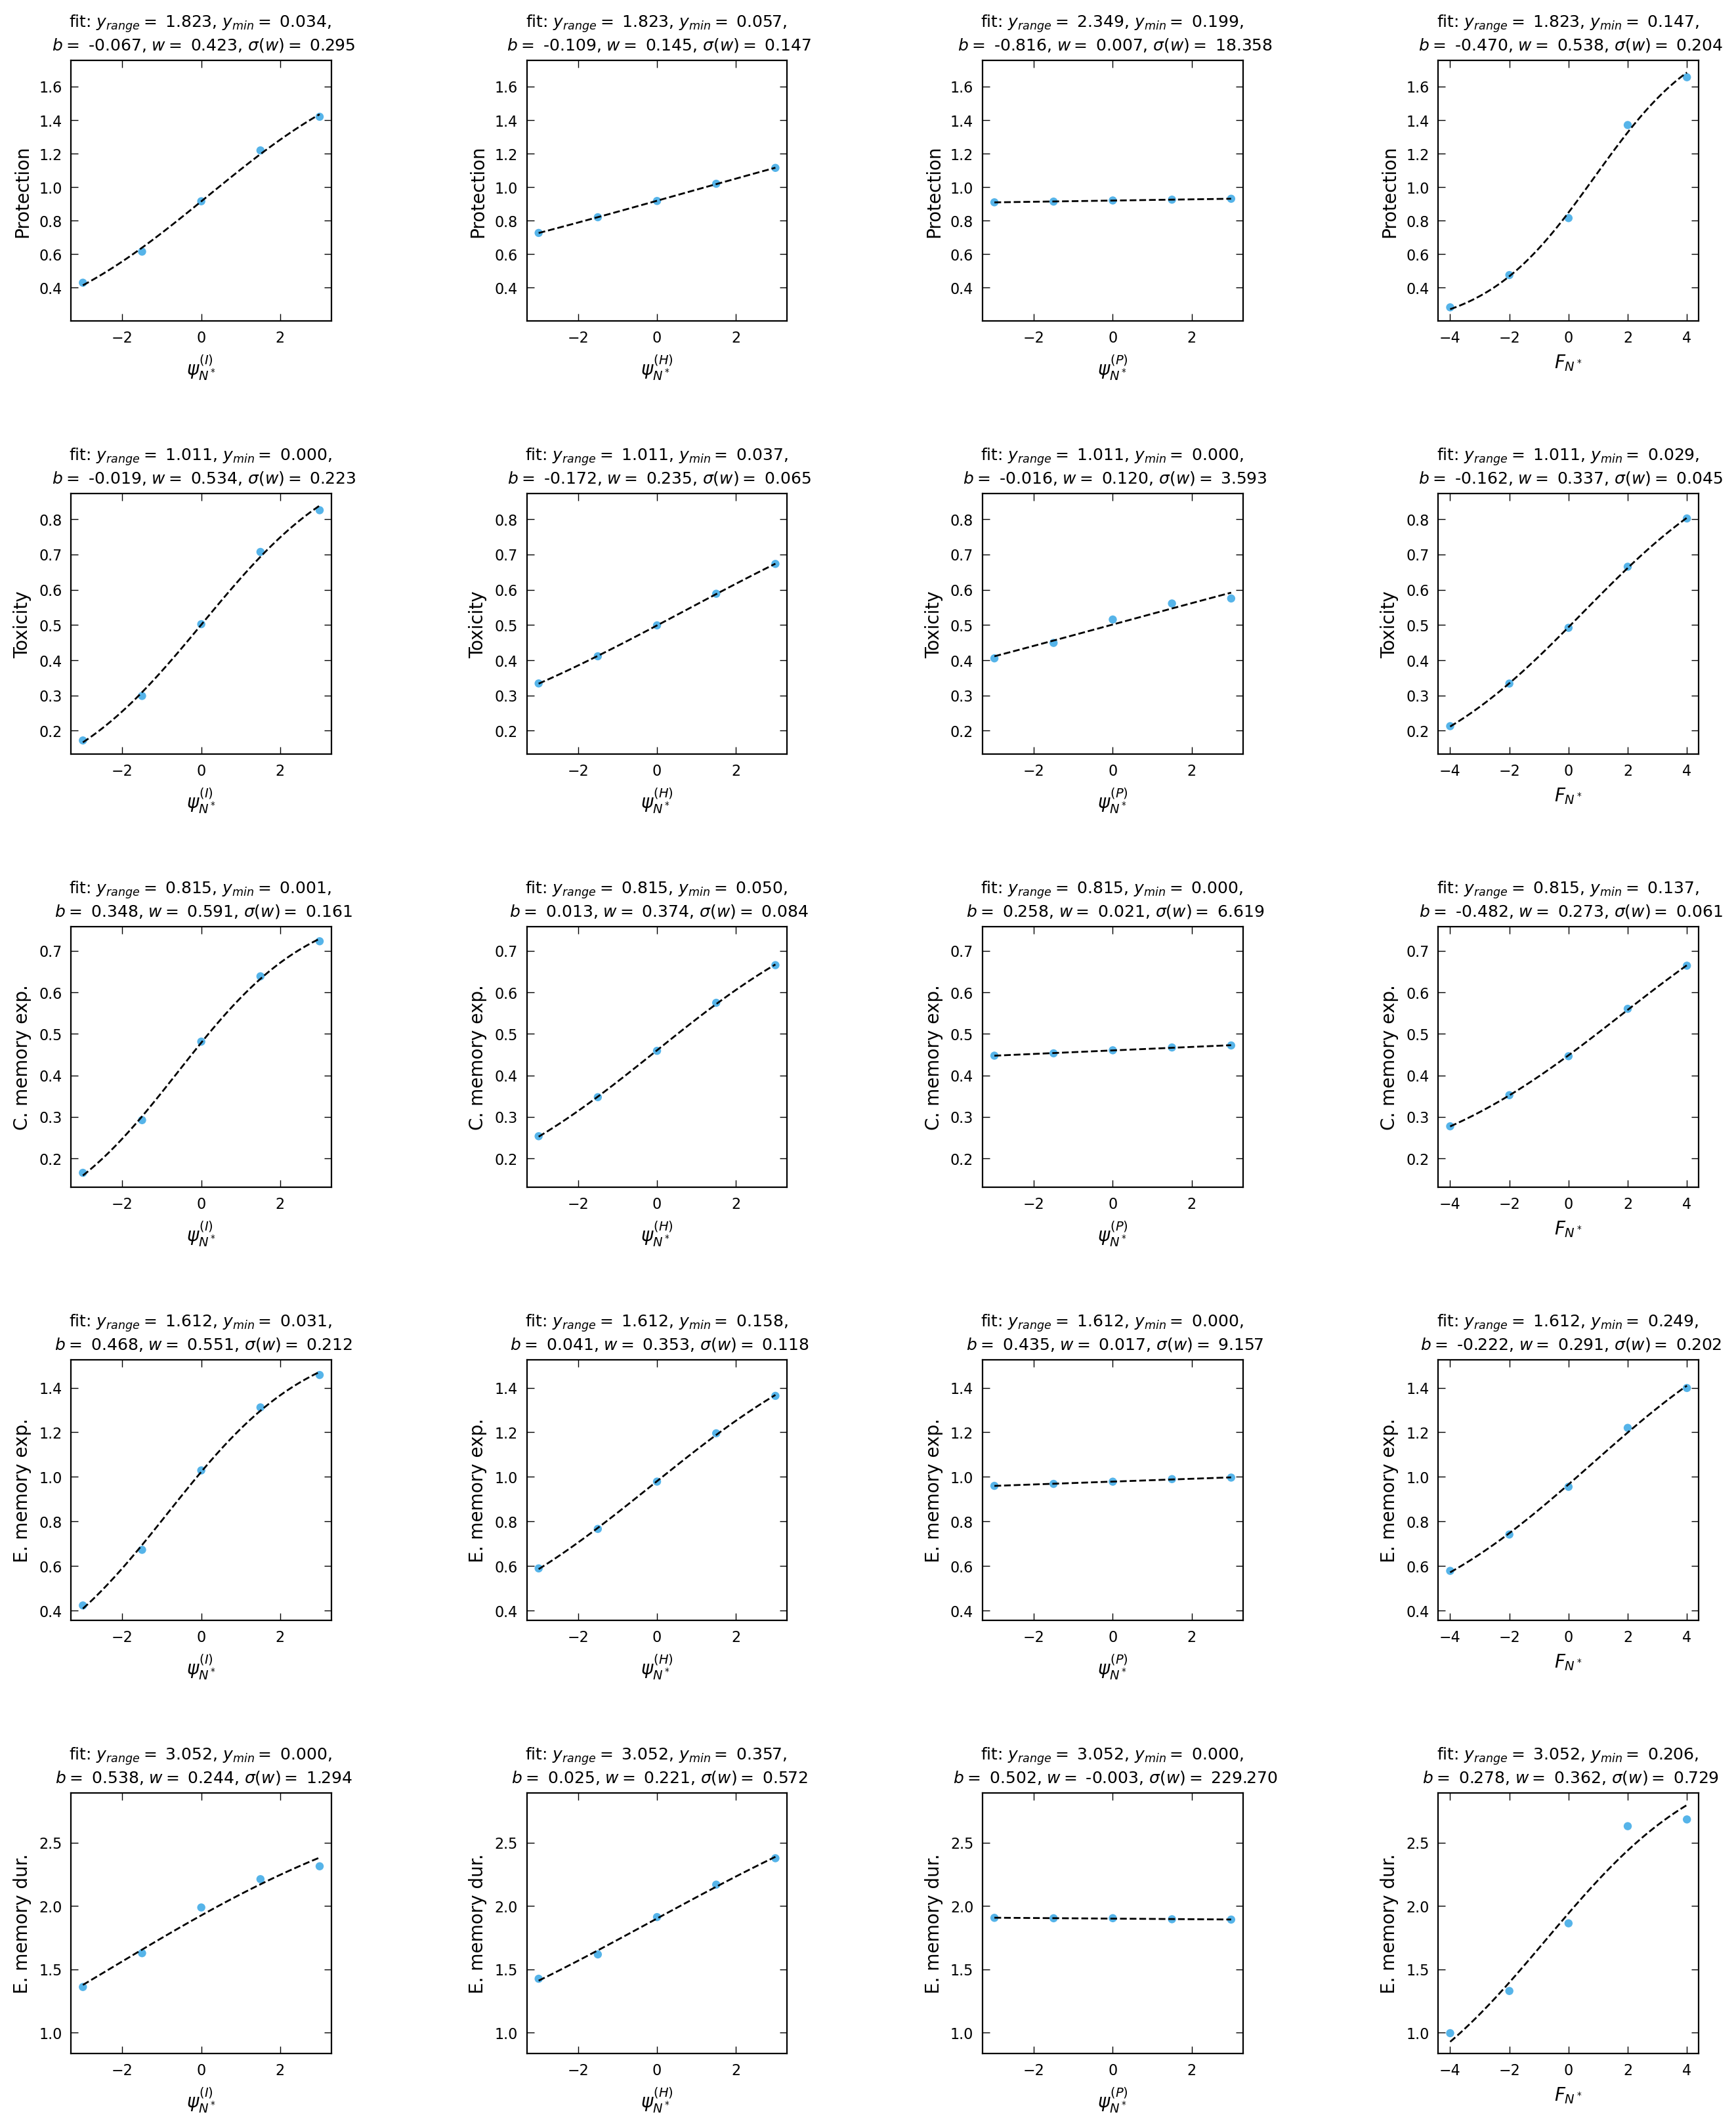

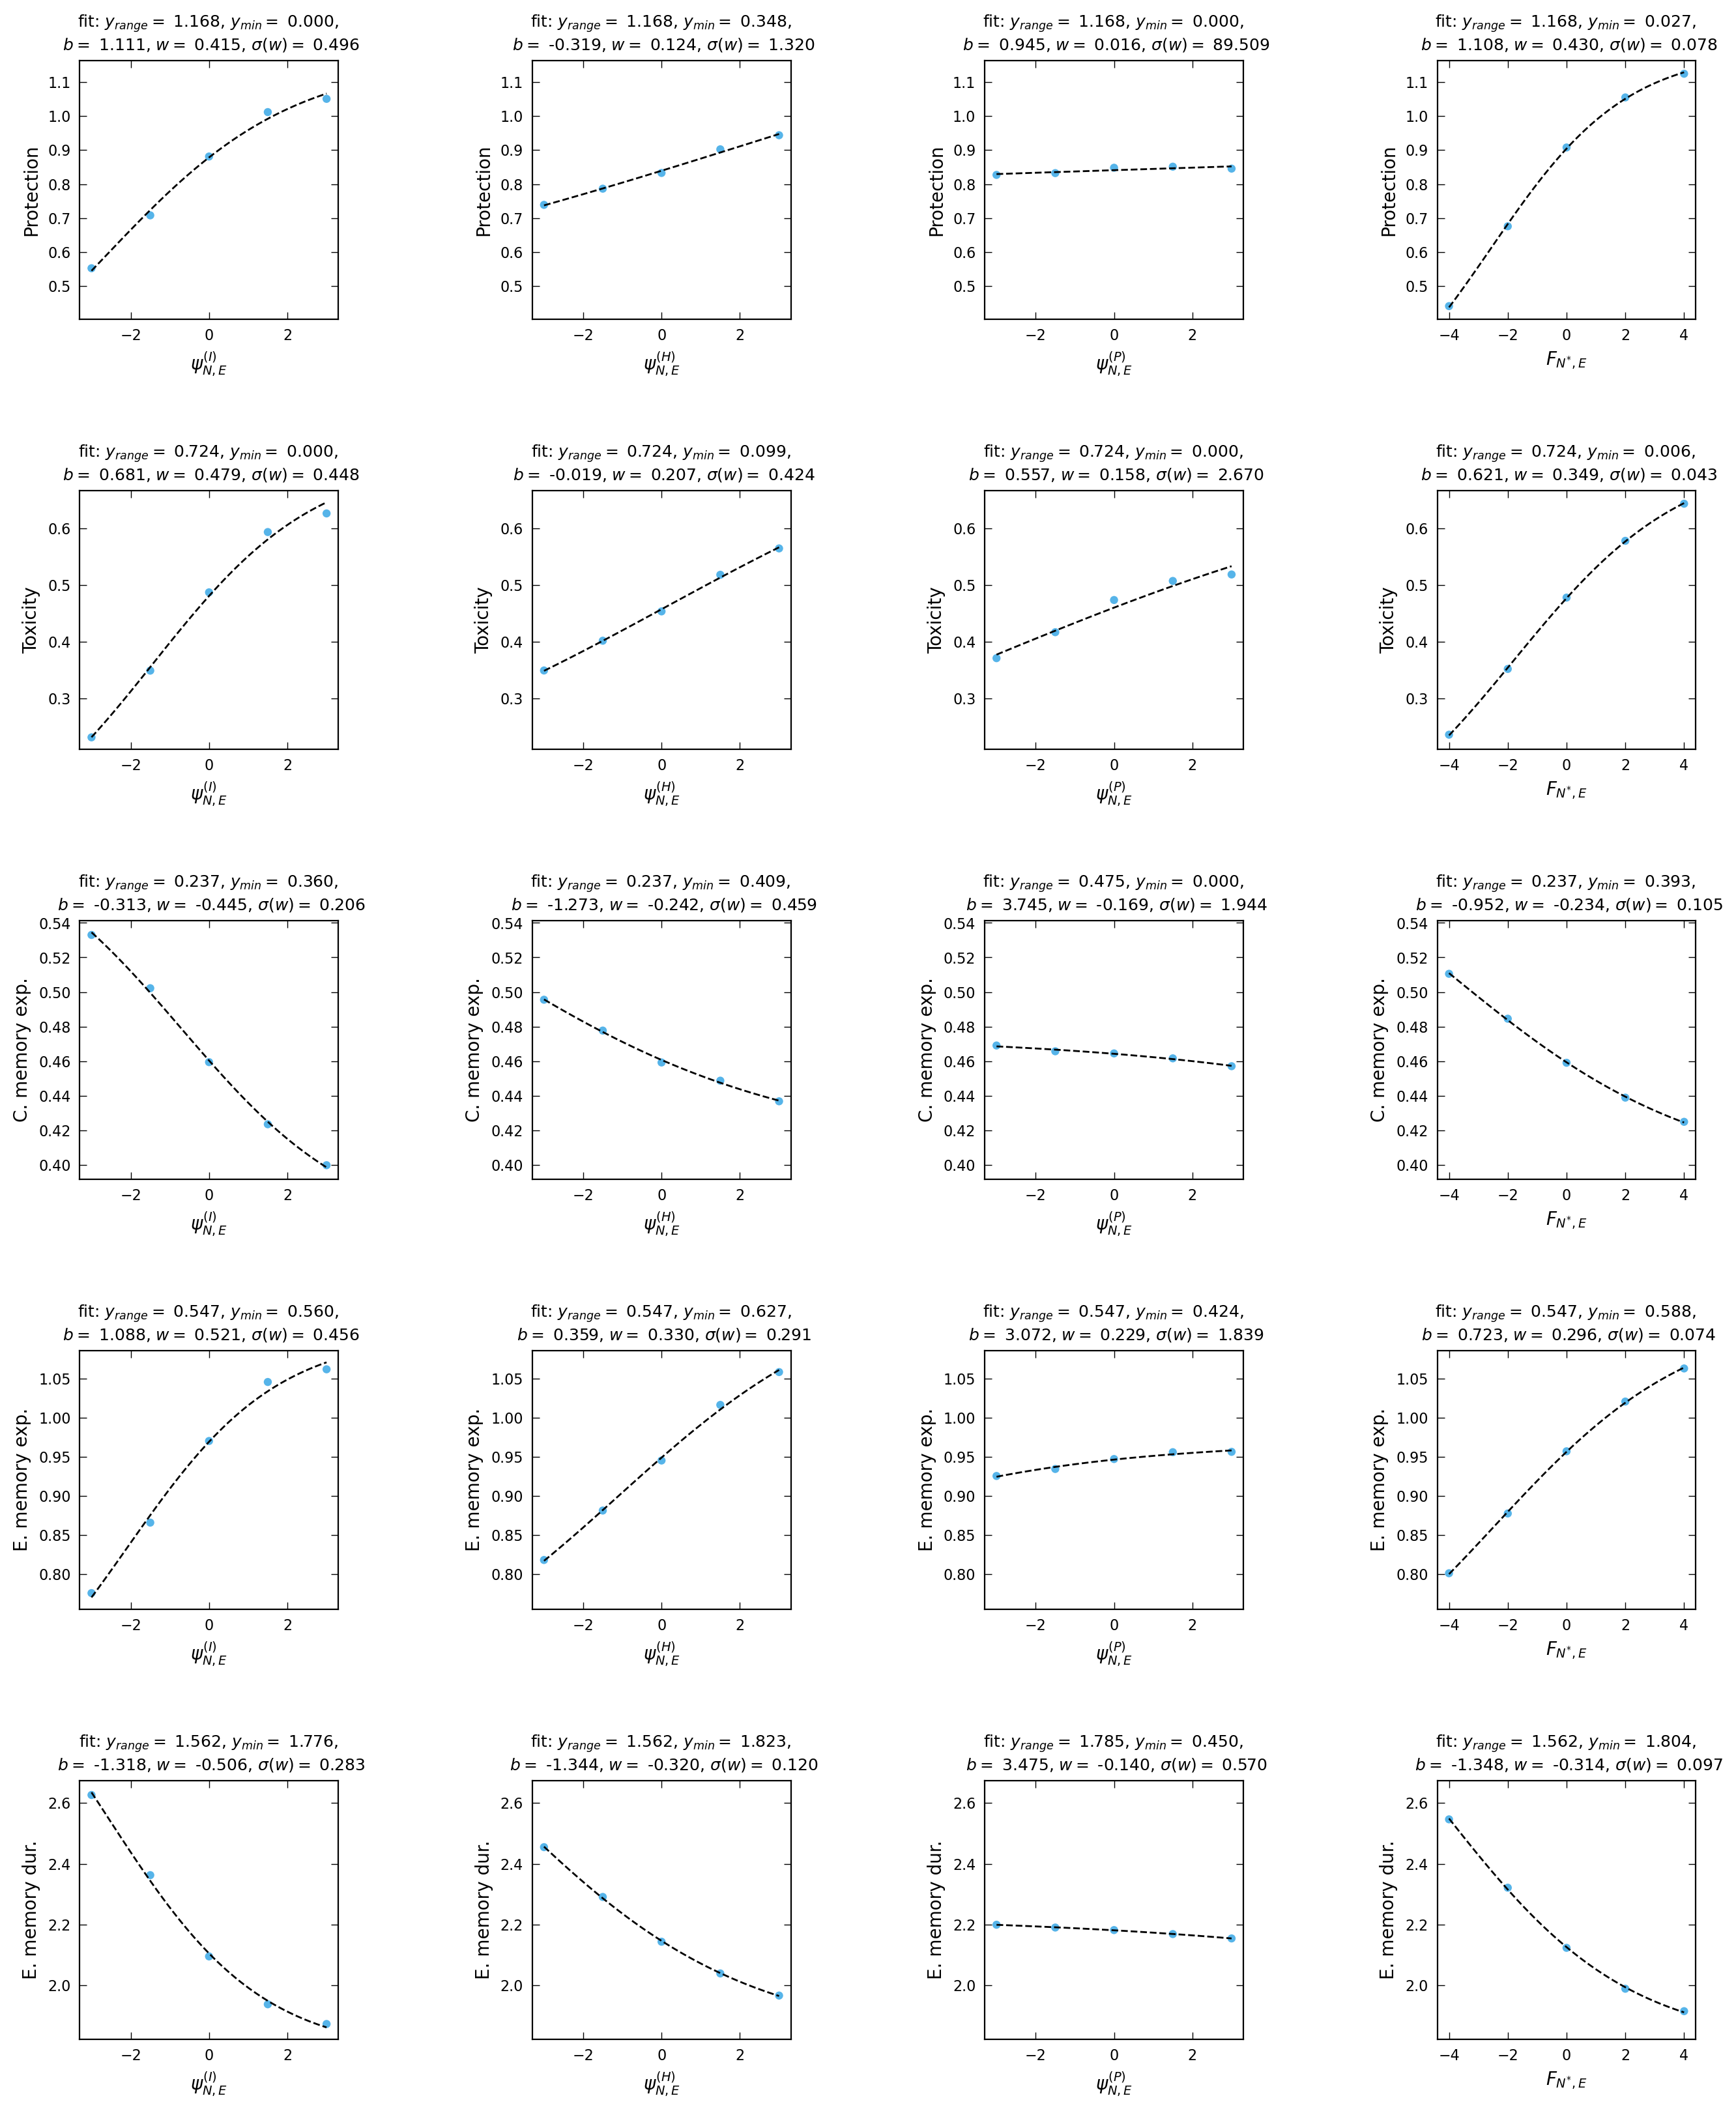

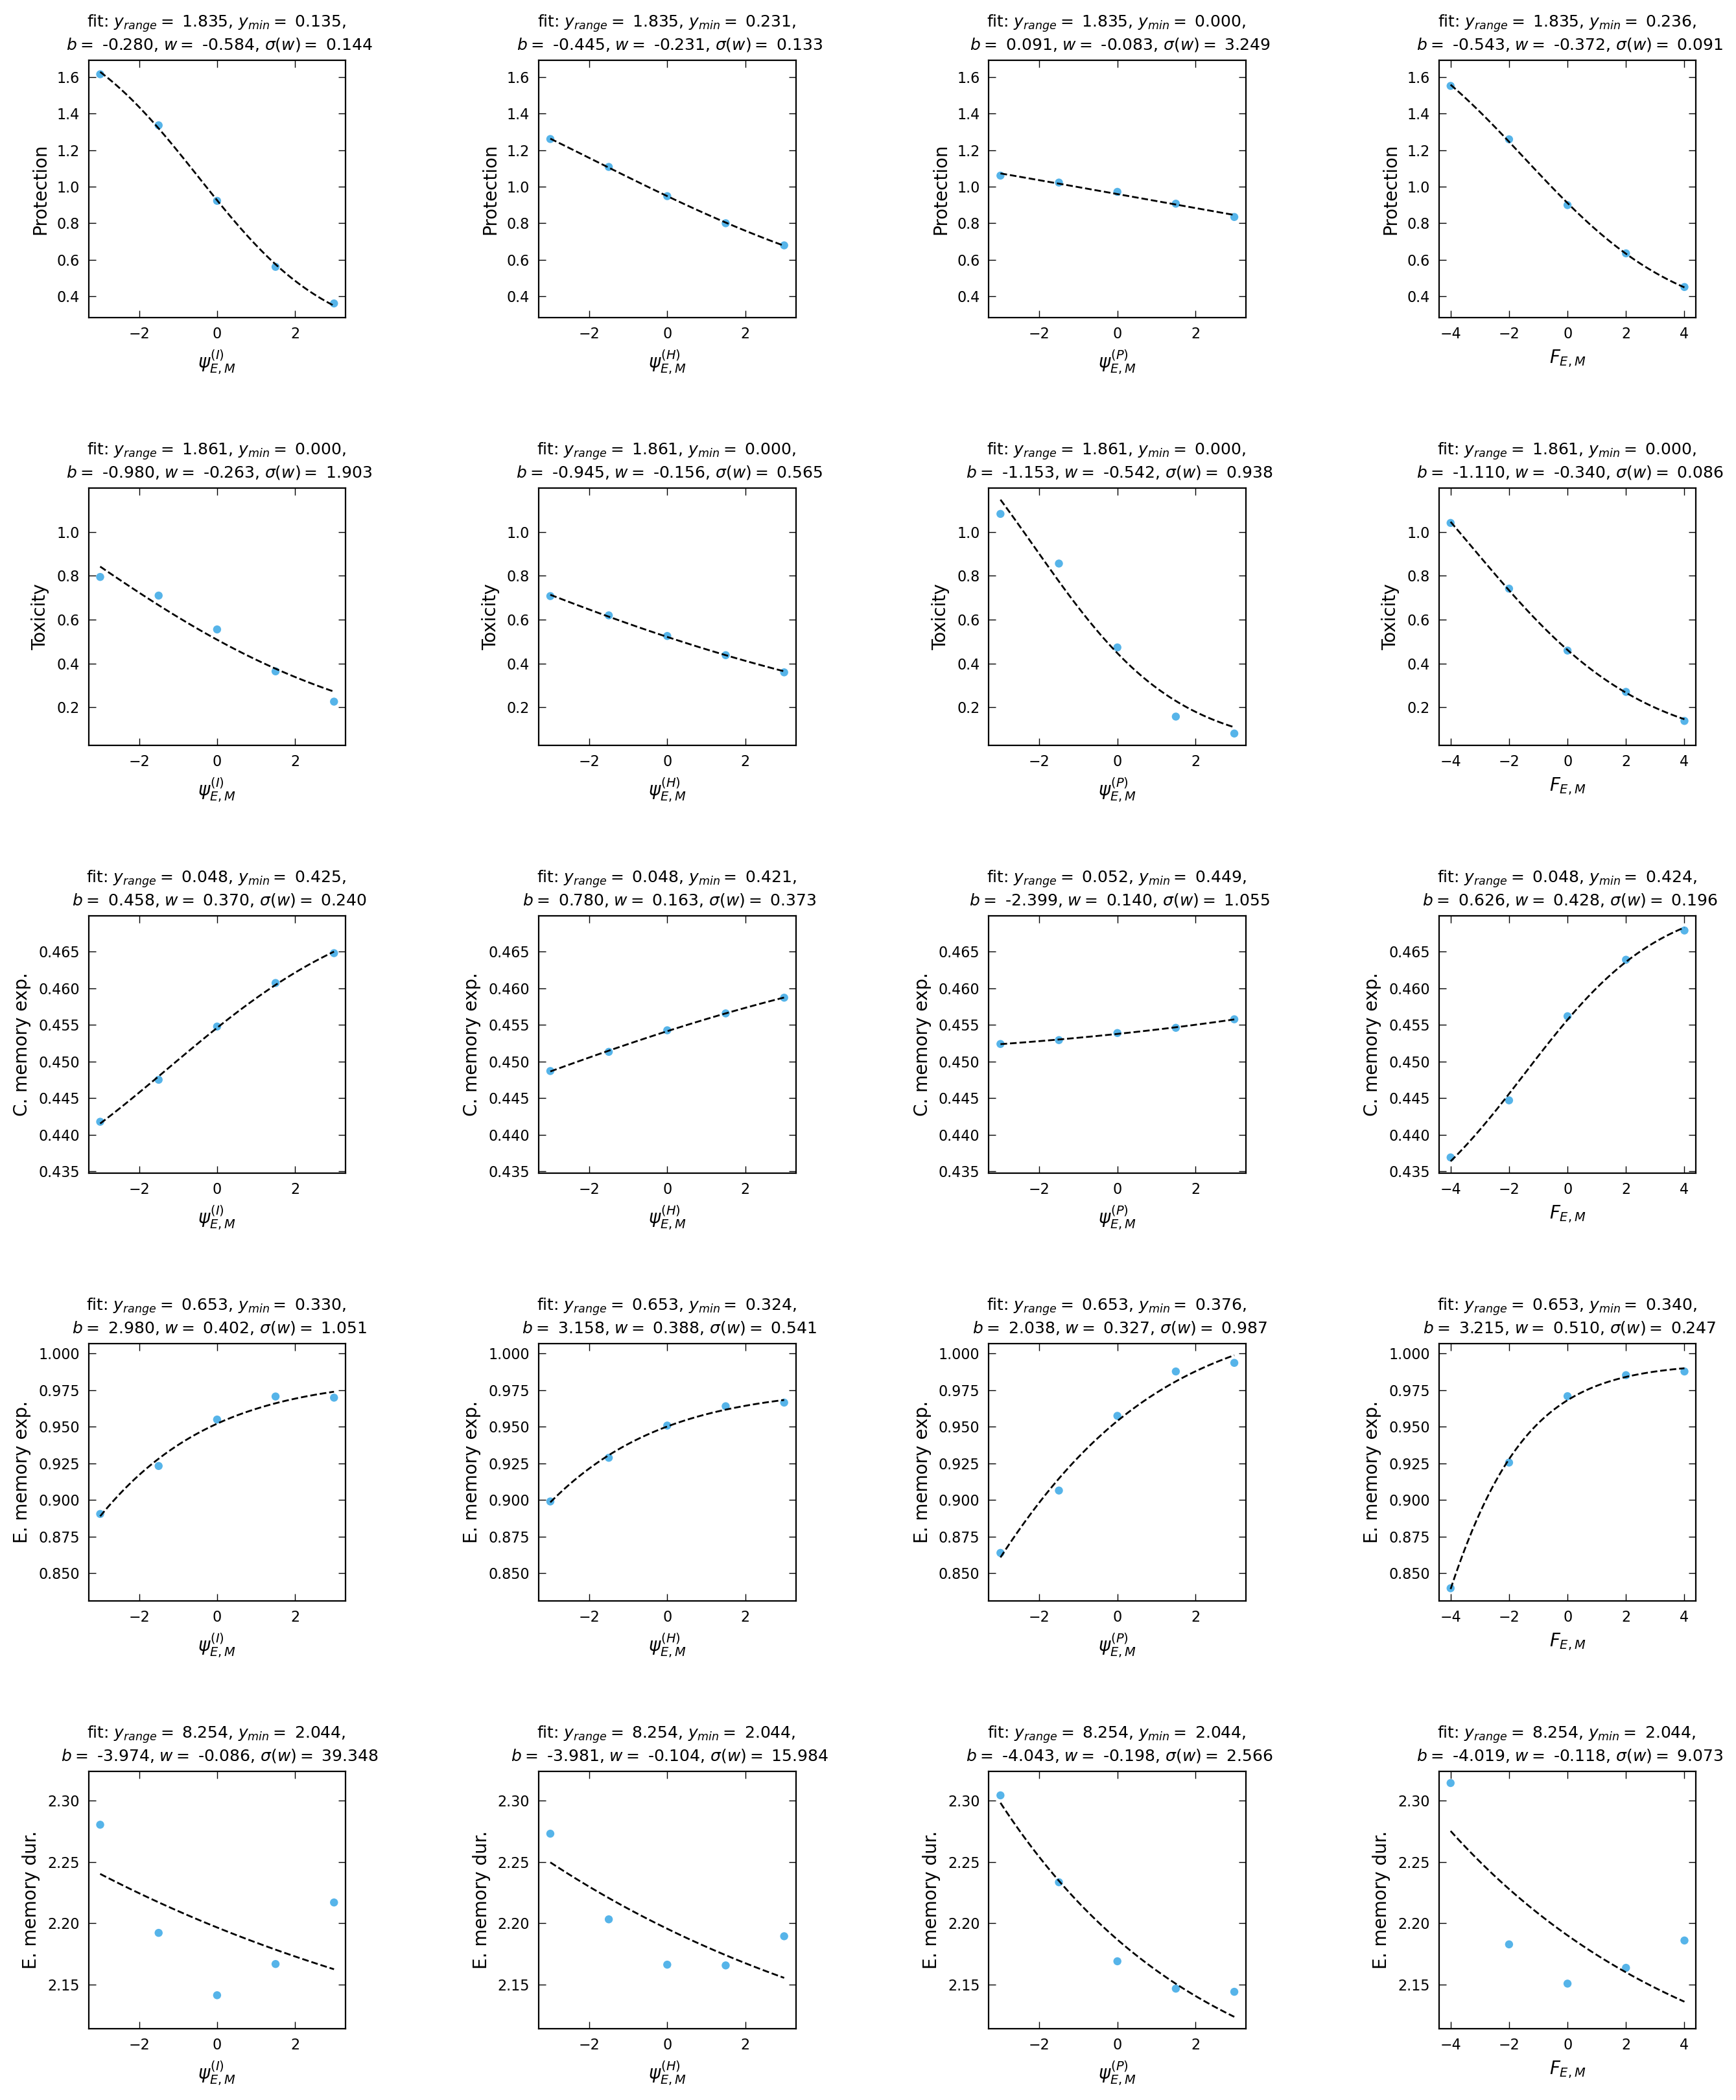

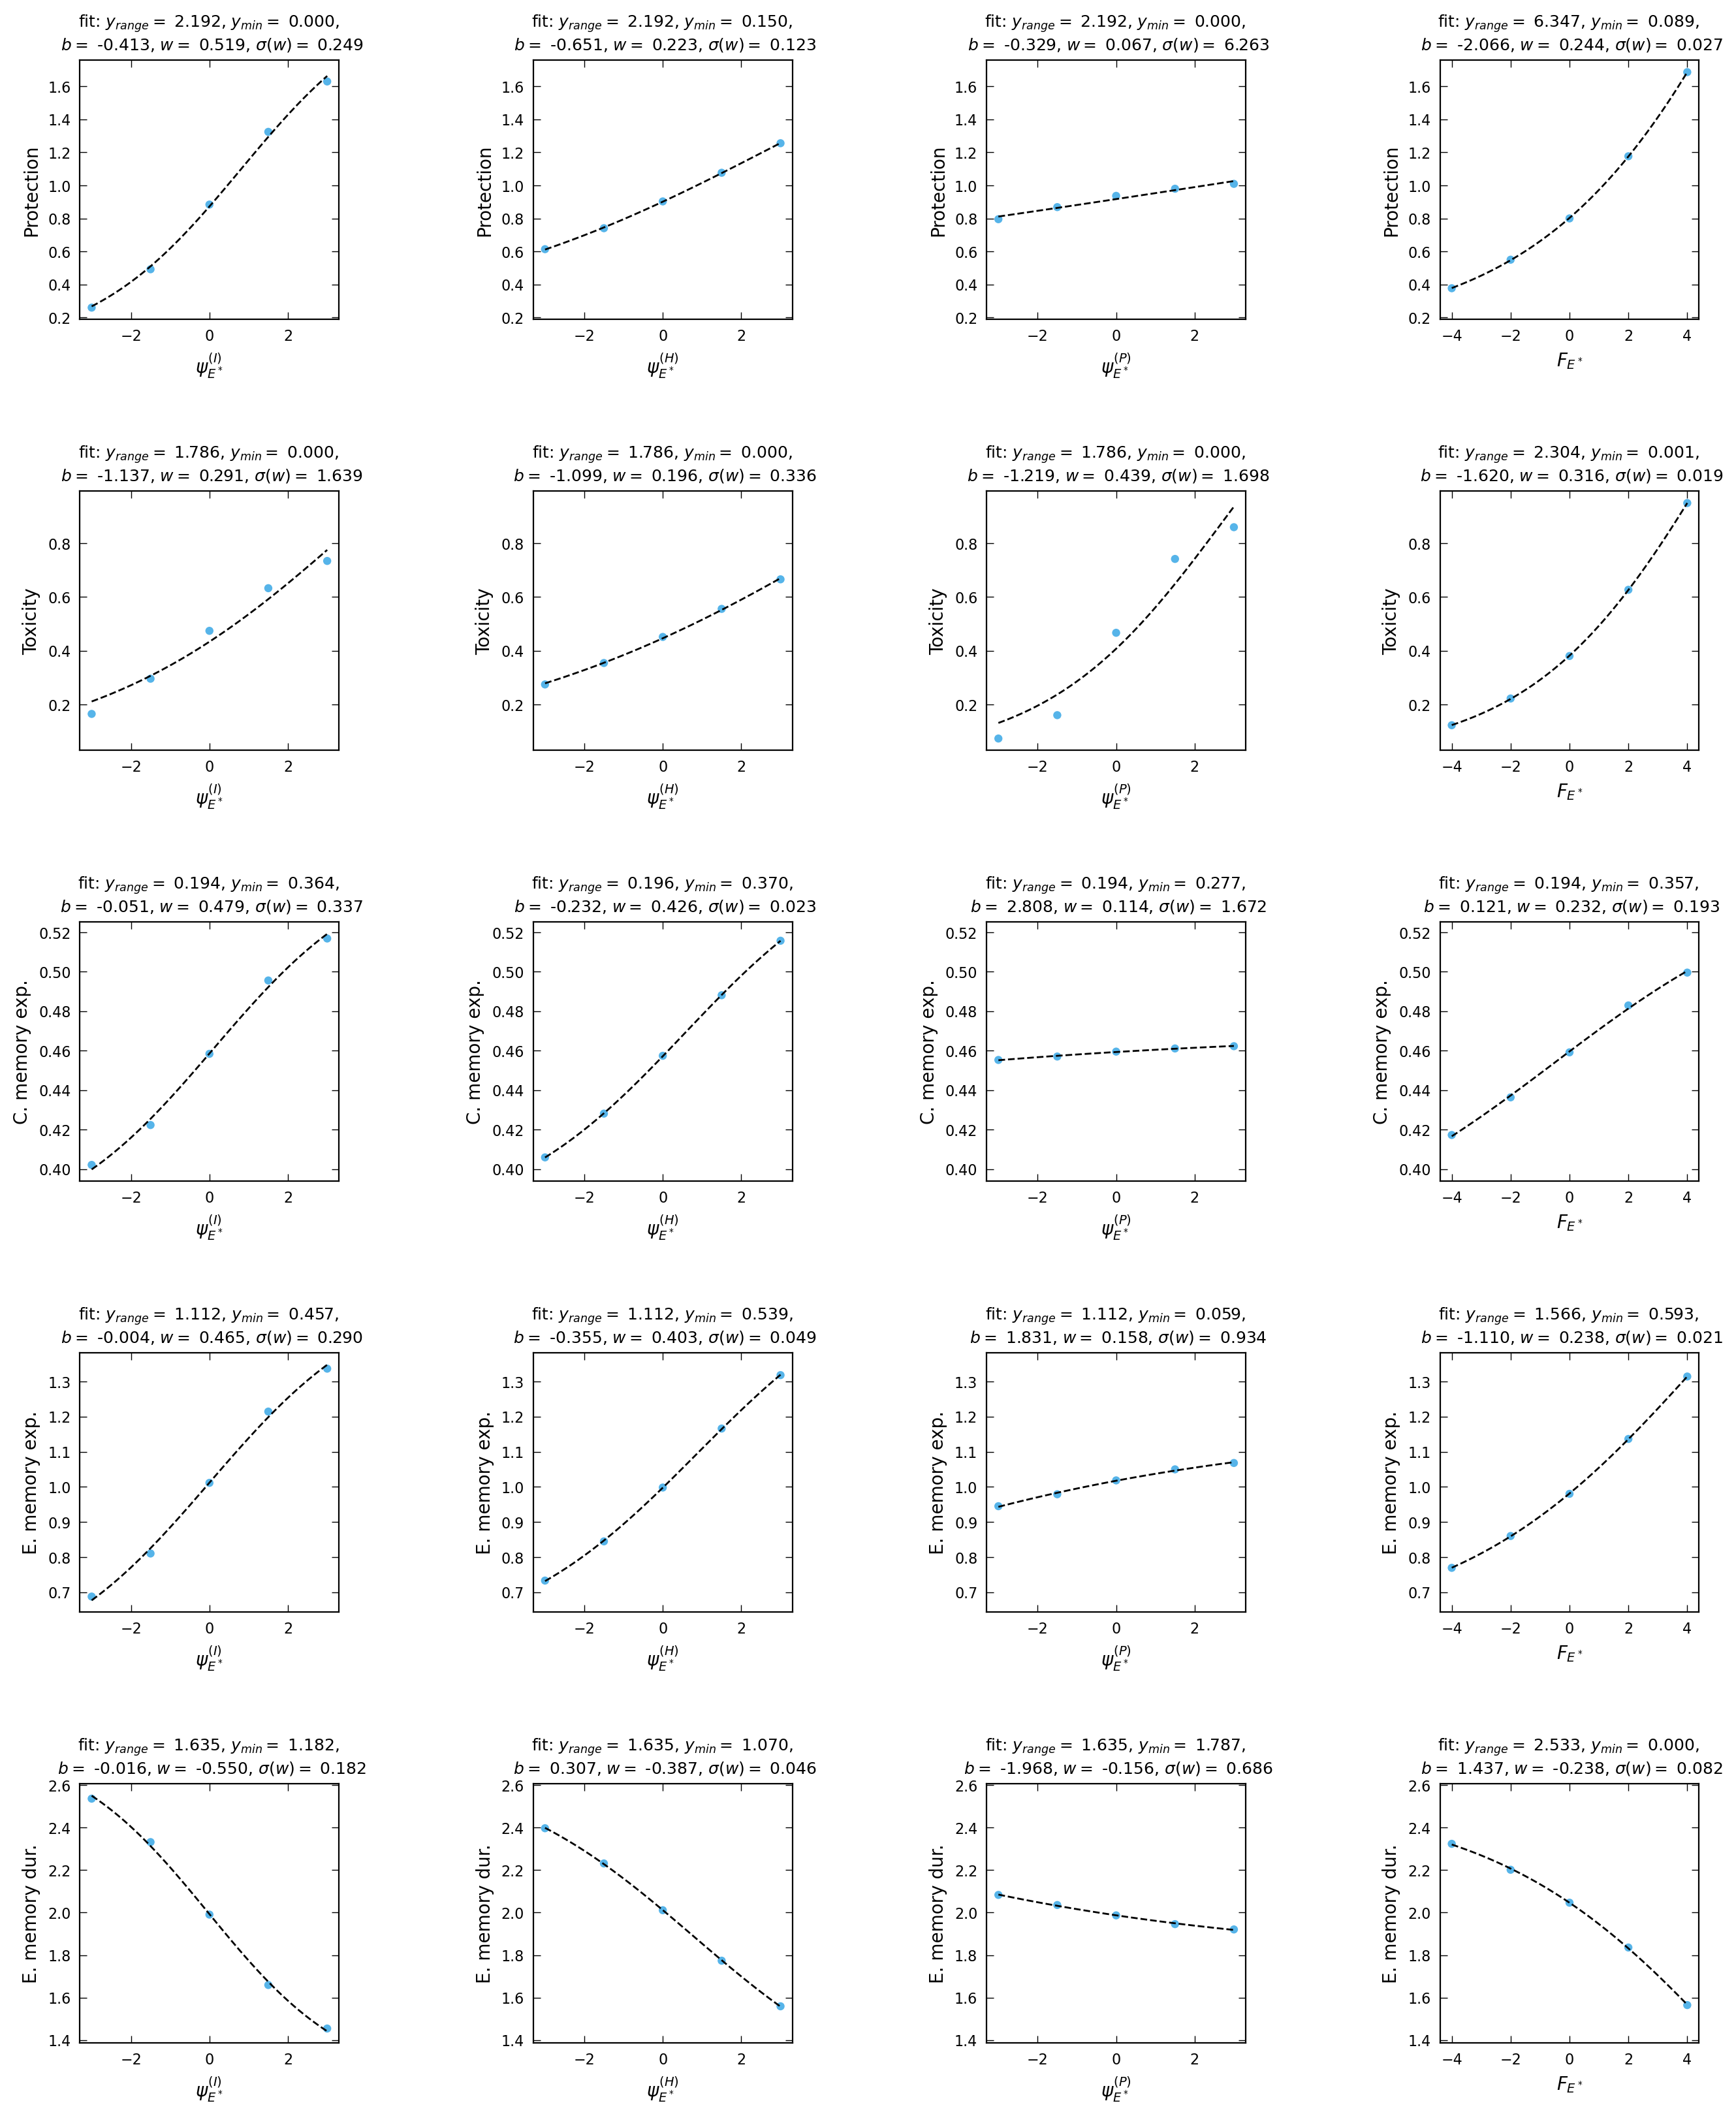

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 130
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min), 0.0 if y_min > 0.0 else y_min] + len(variables)*[-3.0*F0_max] + num_modules*[-3.0*F0_max], 
                                     [1.05*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[3.0*F0_max] + num_modules*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# View result
perf = 3 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
3,2.553926,3.011572e-16,0.311001,0.178558,0.060995,1.648078,0.110183,0.017487,0.060332,0.627193,-0.037184,0.000283,0.011232,-0.627767,0.284492,0.032330,0.075572,1.362241,-0.217551,1.839042,3.869021,-2.939827,0.003734,0.000315,0.002736,0.002598,0.002524,0.006939,0.002129,0.002086,0.002106,0.002100,0.004816,0.004812,0.004812,0.008894,0.001864,0.001673,0.001687,0.004710,0.002865,0.007540,0.036985,0.008059,0.01,50000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.244883,2.553926,0.0,0.000000,3.0,0.136428,0.529686,0.000000,0.180523,0.060789,0.045720,NaN
8,3.030847,8.460697e-03,0.128069,0.053342,0.014751,3.101629,0.060741,0.084025,0.001845,0.651460,-0.018226,-0.006132,-0.001306,-0.692590,0.105849,0.037287,0.009009,0.971616,1.825217,2.051138,4.488607,-2.250335,0.005113,0.000392,0.004694,0.004688,0.004684,0.026722,0.001913,0.001919,0.001907,0.001983,0.005551,0.005550,0.005550,0.012150,0.001169,0.001138,0.001133,0.002610,0.006149,0.007219,0.050260,0.003426,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.364552,2.886521,0.0,0.000000,3.0,0.153683,0.664398,0.000000,0.094331,0.060789,0.021779,NaN
13,2.985022,9.957284e-03,0.132258,0.062229,0.025061,3.085127,0.057572,0.084389,0.009283,0.644823,-0.017122,-0.010263,0.001482,-0.704068,0.112928,0.038209,0.021977,0.995201,1.807819,2.072509,4.555051,-2.242385,0.004562,0.000381,0.004465,0.004458,0.004454,0.025346,0.001857,0.001863,0.001851,0.001939,0.005462,0.005462,0.005462,0.012213,0.001162,0.001131,0.001128,0.002543,0.005868,0.007126,0.050465,0.003444,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.369631,2.842878,0.0,0.000000,3.0,0.149679,0.668427,0.000000,0.094330,0.060789,0.048841,NaN
18,2.802069,2.278442e-03,0.102026,0.051040,0.040609,2.837792,0.061725,0.069239,0.025117,0.653465,-0.018313,-0.004432,0.001884,-0.685128,0.126346,0.037732,0.055879,1.071665,1.443484,1.991020,4.324946,-2.584940,0.004662,0.000326,0.003503,0.003495,0.003494,0.021802,0.001814,0.001815,0.001809,0.001856,0.004820,0.004819,0.004819,0.010138,0.001184,0.001136,0.001142,0.003061,0.004417,0.006676,0.041931,0.004292,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.307692,2.797058,0.0,0.000289,3.0,0.131372,0.595869,0.000000,0.094329,0.060789,0.065034,NaN
23,3.009200,6.709602e-03,0.136315,0.081943,0.071685,2.895694,0.056445,0.082000,0.039612,0.628904,-0.017205,-0.006328,-0.006211,-0.726112,0.107575,0.037383,0.099413,0.961346,1.736143,2.043673,4.709303,-2.173553,0.004824,0.000394,0.004304,0.004294,0.004292,0.019224,0.001896,0.001902,0.001893,0.001982,0.005930,0.005929,0.005929,0.013890,0.001169,0.001138,0.001164,0.002463,0.005720,0.007345,0.057292,0.003272,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.370142,2.865905,0.0,0.000366,3.0,0.153863,0.666654,0.000000,0.094315,0.060789,0.163772,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,3.038834,9.298767e-40,0.214303,2.935538,0.008452,2.450807,0.061481,0.626839,0.012185,0.617593,0.016882,0.145513,0.086600,-0.062396,0.144992,1.423200,0.010392,1.227980,1.467787,2.027494,2.087180,-2.456846,0.028546,0.000427,0.003835,0.013946,0.003755,0.010818,0.002367,0.003078,0.002

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

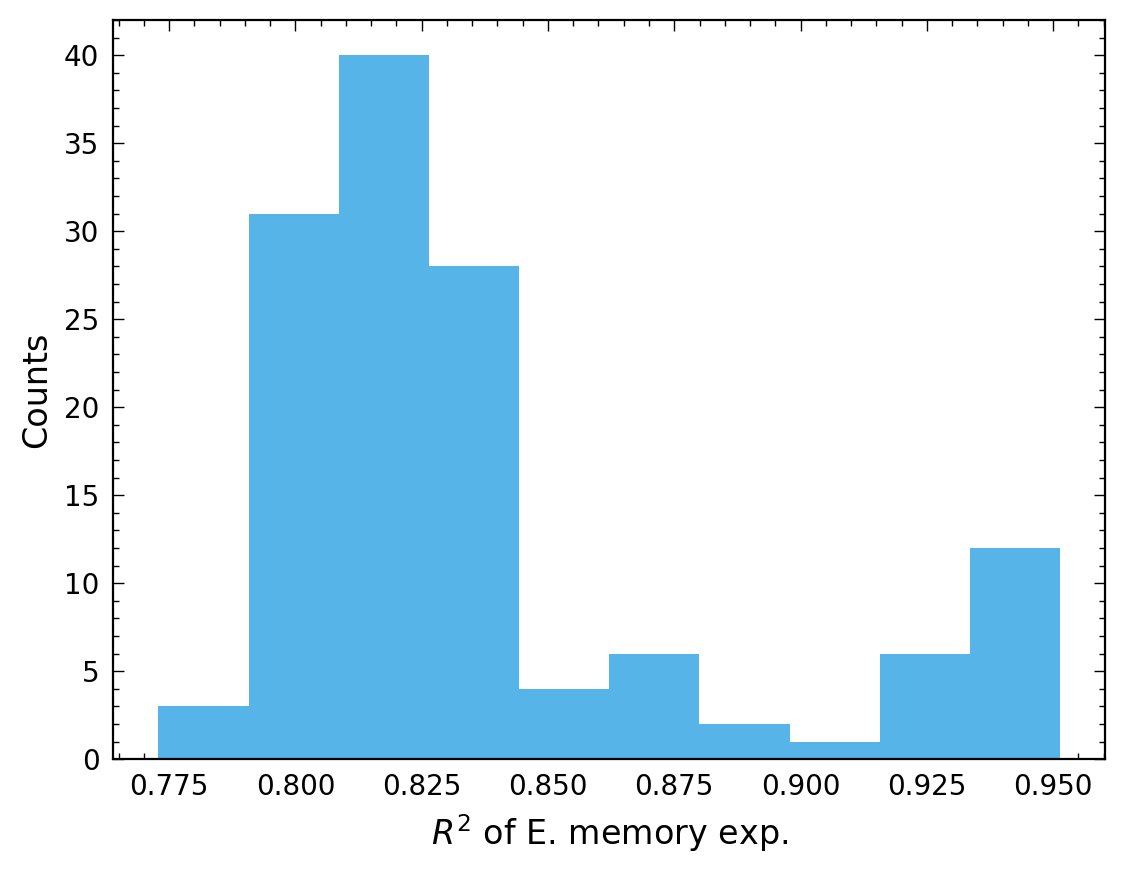

In [11]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

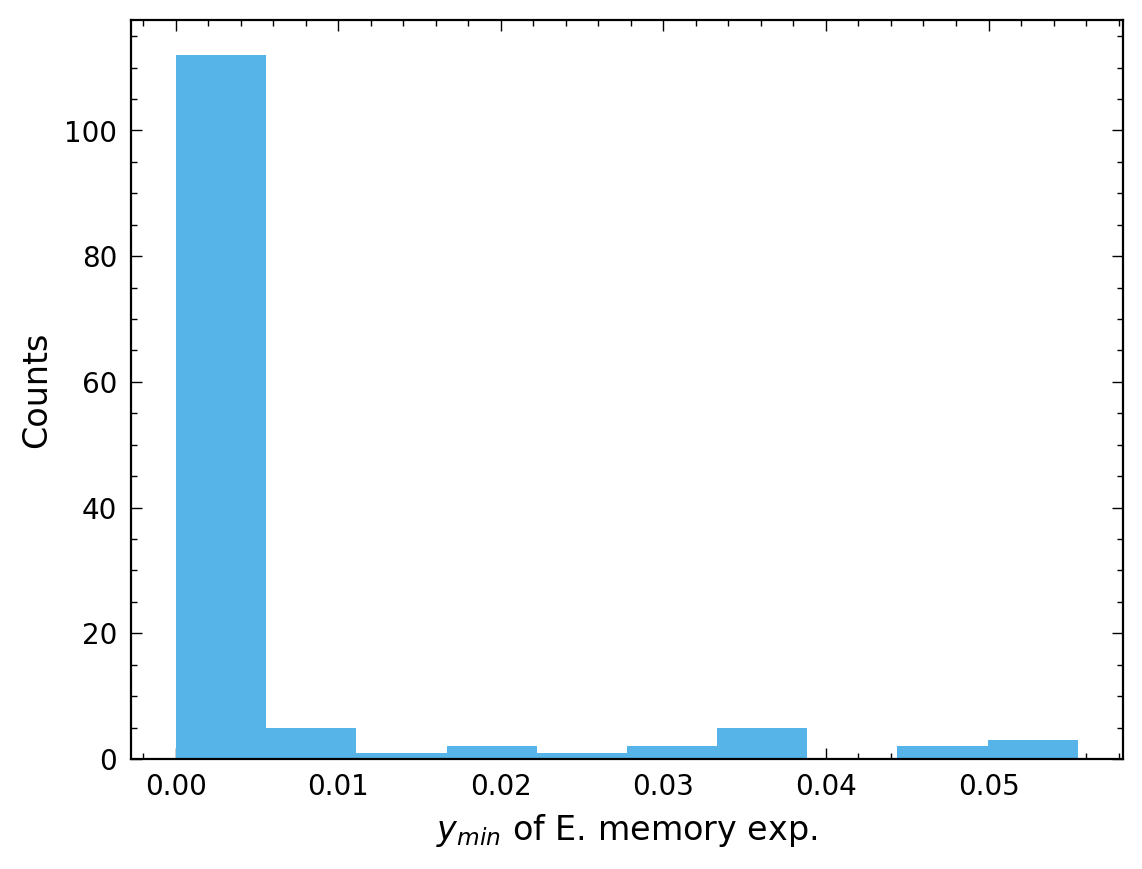

In [12]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

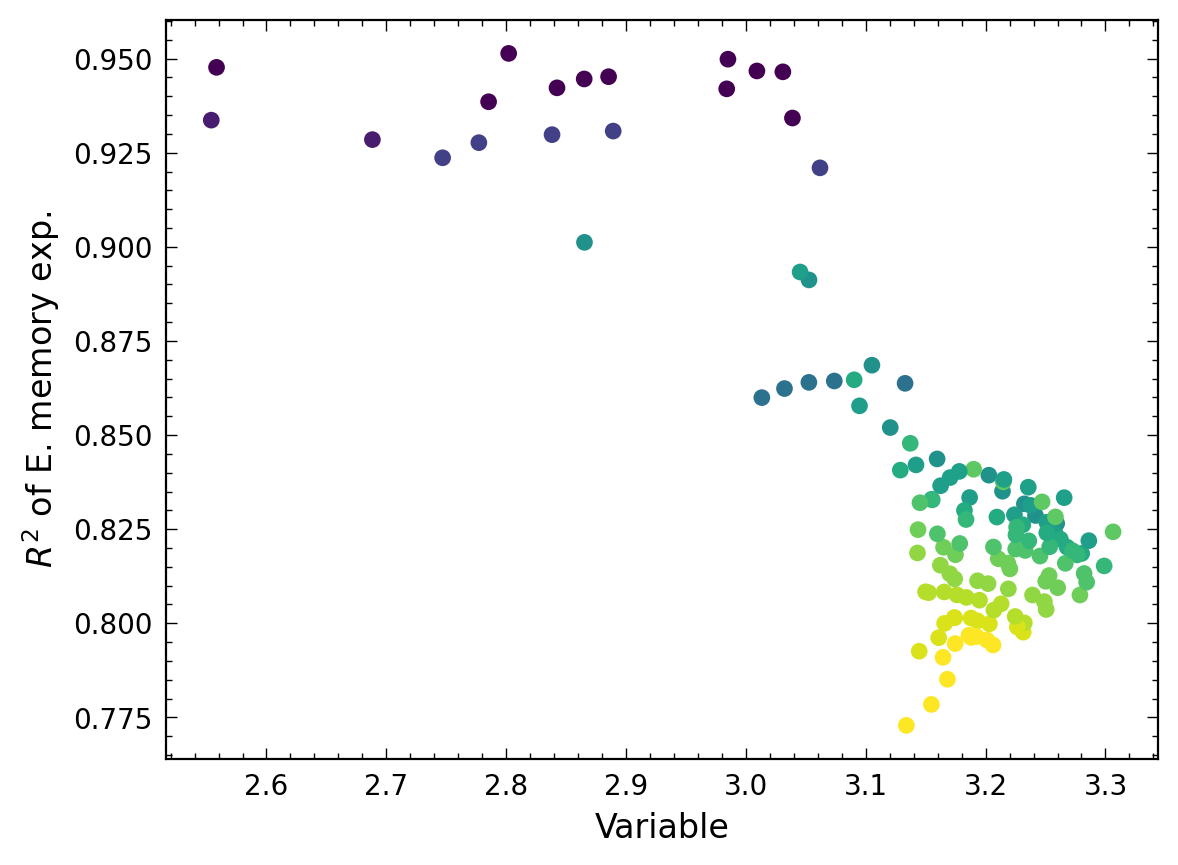

In [13]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)].y_range, model_r_sq, 
            c = 1/impact_data.loc[(impact_data.perf_index == perf)].K_IE, norm=mpl.colors.LogNorm());
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

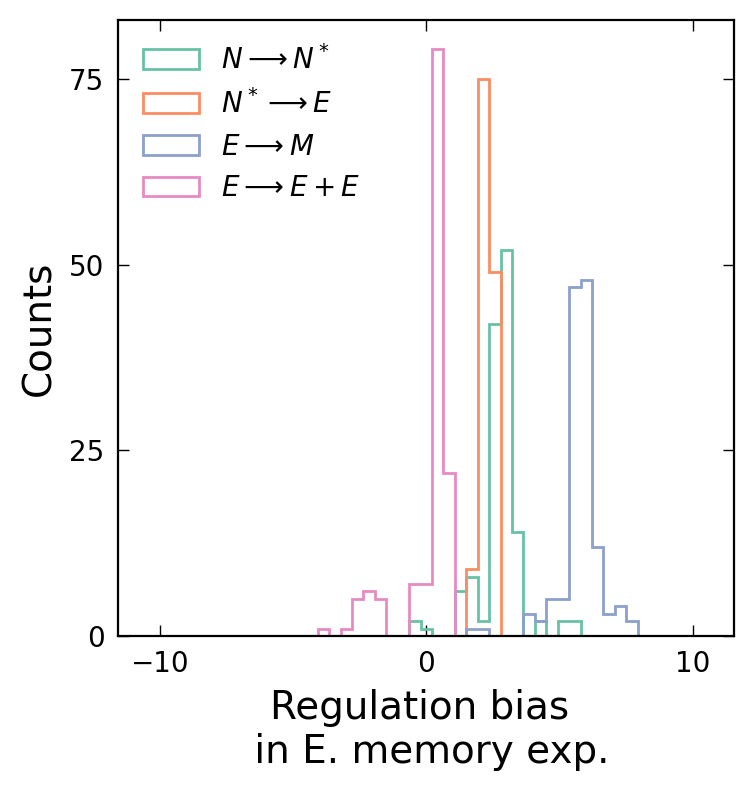

In [14]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

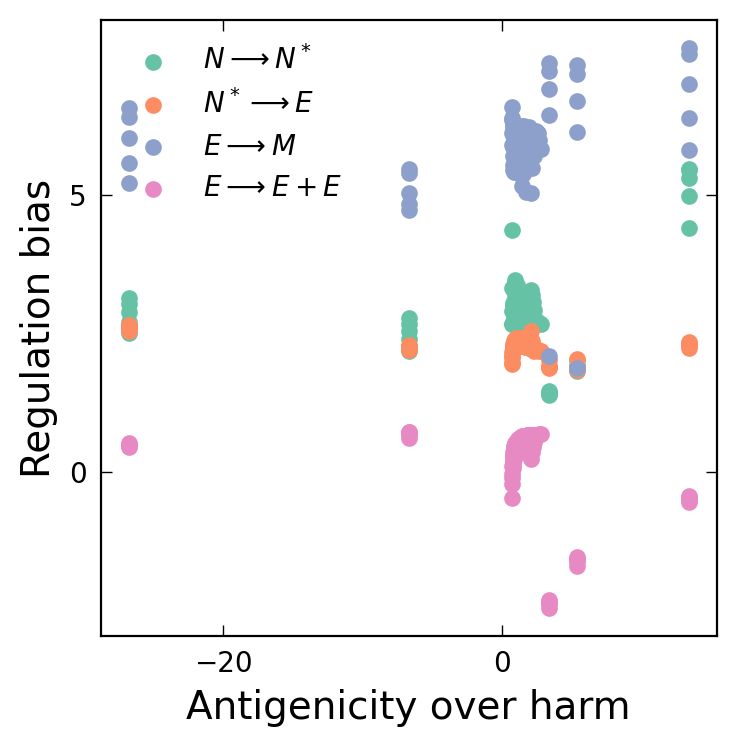

In [15]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

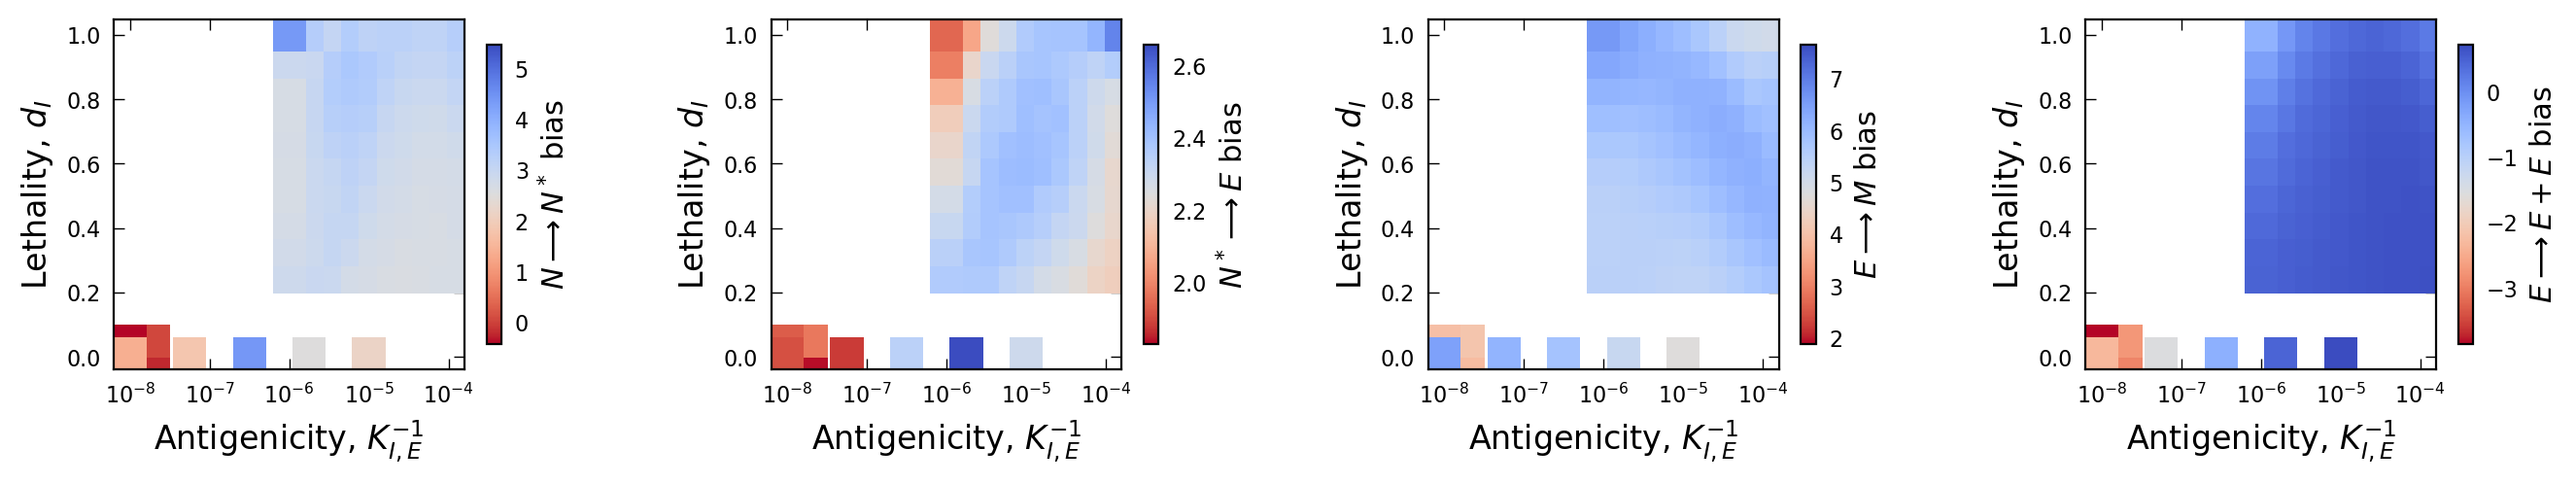

In [16]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

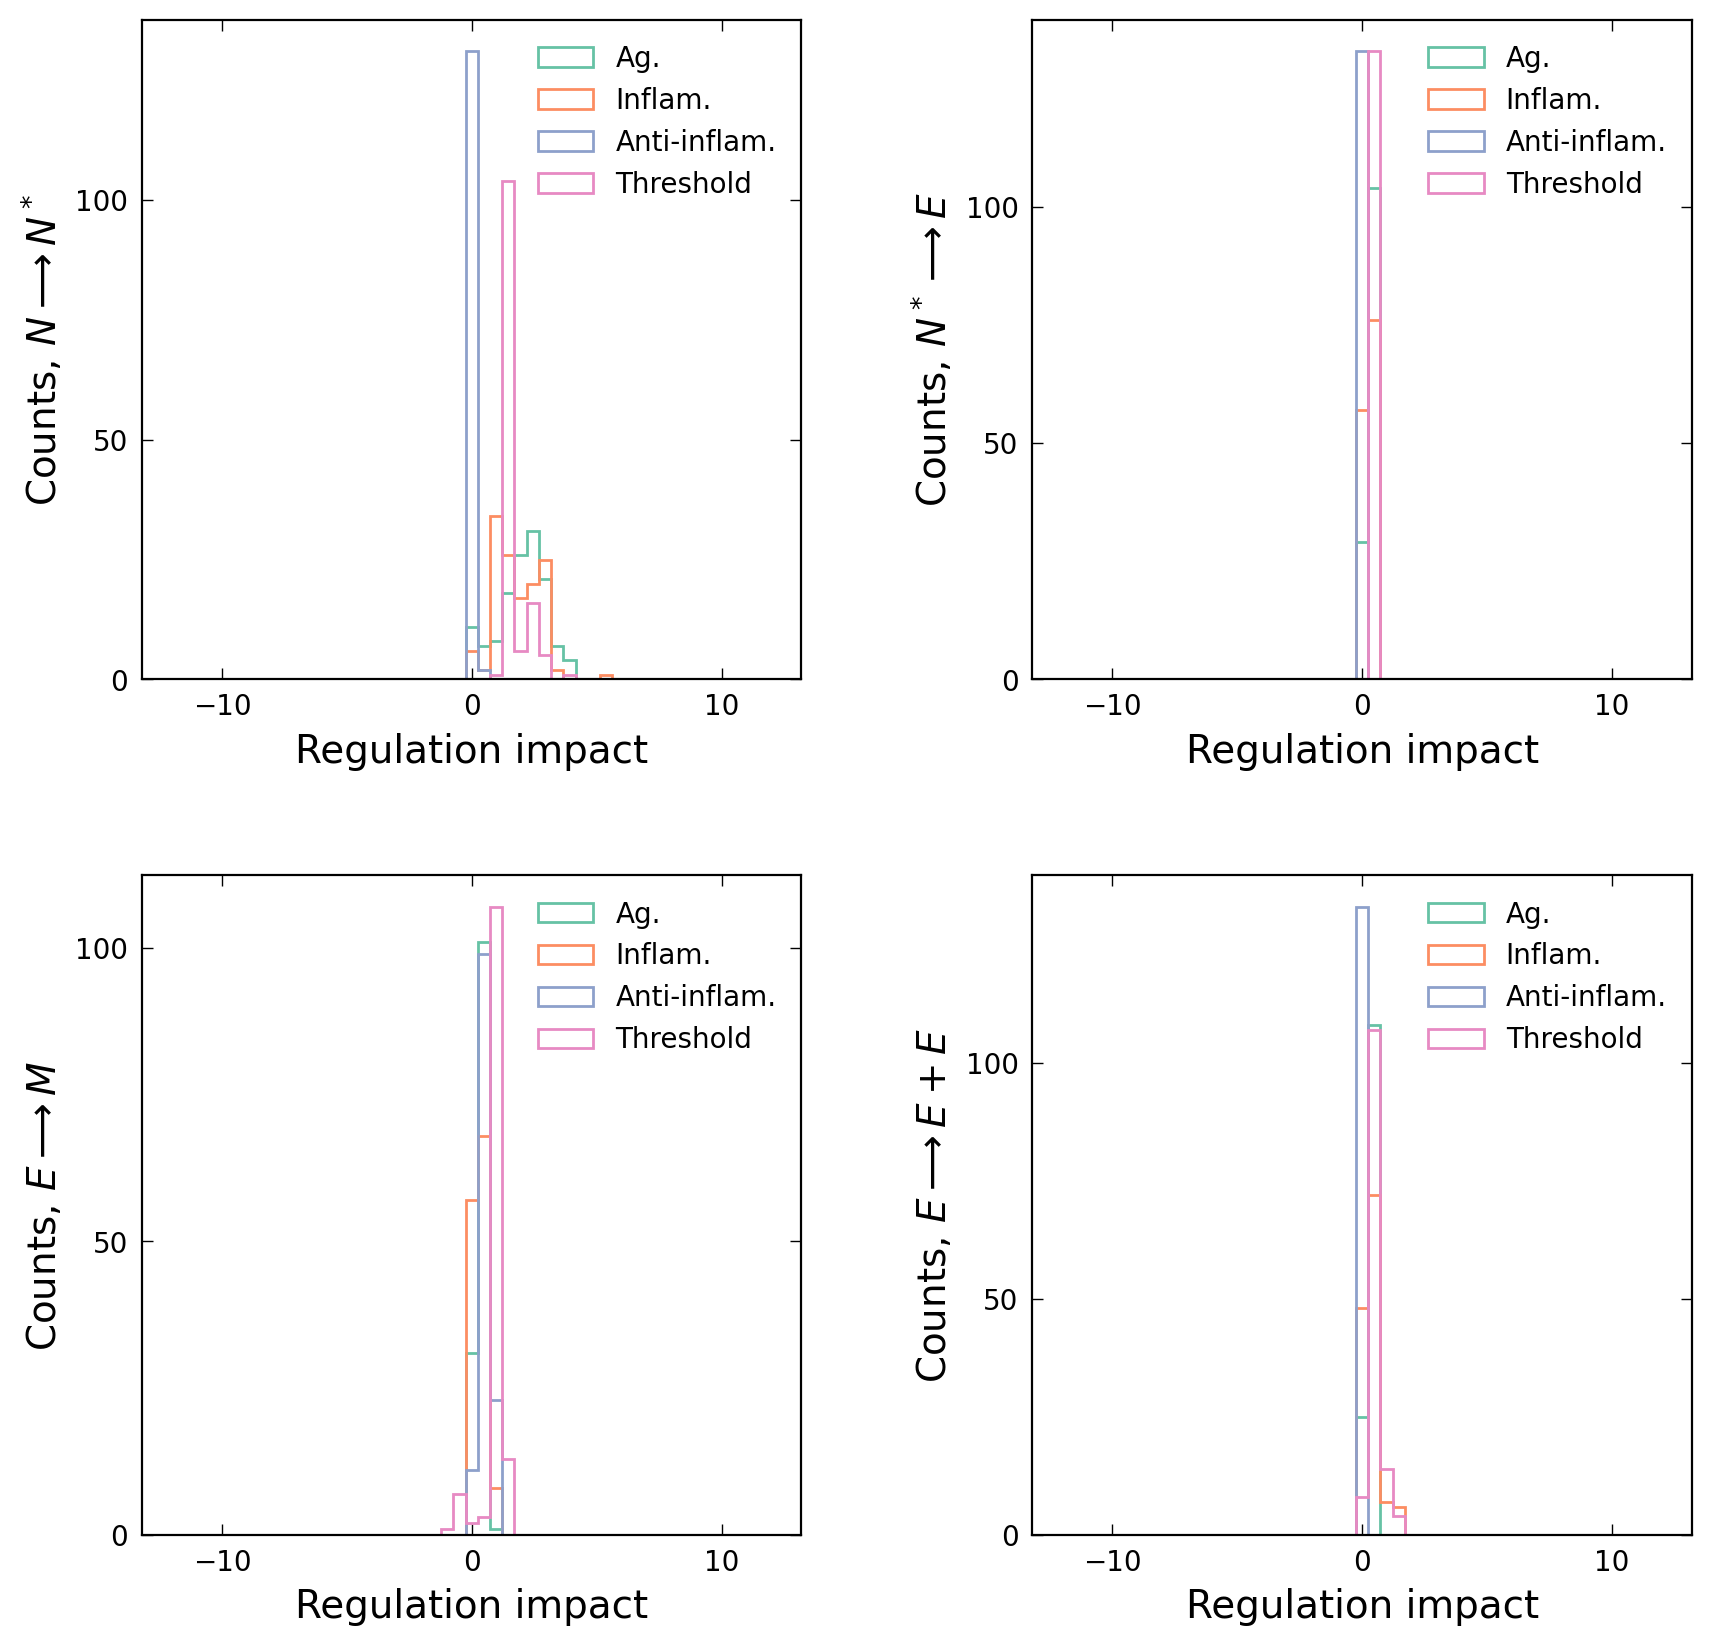

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*F0_max, 3.0*F0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [18]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
3,2.553926,3.011572e-16,0.311001,0.178558,0.060995,1.648078,0.110183,0.017487,0.060332,0.627193,-0.037184,0.000283,0.011232,-0.627767,0.284492,0.032330,0.075572,1.362241,-0.217551,1.839042,3.869021,-2.939827,0.003734,0.000315,0.002736,0.002598,0.002524,0.006939,0.002129,0.002086,0.002106,0.002100,0.004816,0.004812,0.004812,0.008894,0.001864,0.001673,0.001687,0.004710,0.002865,0.007540,0.036985,0.008059,0.01,50000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.244883,2.553926,0.0,0.000000,3.0,0.136428,0.529686,0.0,0.180523,0.060789,0.045720,NaN
8,3.030847,8.460697e-03,0.128069,0.053342,0.014751,3.101629,0.060741,0.084025,0.001845,0.651460,-0.018226,-0.006132,-0.001306,-0.692590,0.105849,0.037287,0.009009,0.971616,1.825217,2.051138,4.488607,-2.250335,0.005113,0.000392,0.004694,0.004688,0.004684,0.026722,0.001913,0.001919,0.001907,0.001983,0.005551,0.005550,0.005550,0.012150,0.001169,0.001138,0.001133,0.002610,0.006149,0.007219,0.050260,0.003426,0.01,100000000.0,0.0,50000.0,30.000000,10000000.0,0.0,0.364552,2.886521,0.0,0.000000,3.0,0.153683,0.664398,0.0,0.094331,0.060789,0.021779,NaN
13,2.985022,9.957284e-03,0.132258,0.062229,0.025061,3.085127,0.057572,0.084389,0.009283,0.644823,-0.017122,-0.010263,0.001482,-0.704068,0.112928,0.038209,0.021977,0.995201,1.807819,2.072509,4.555051,-2.242385,0.004562,0.000381,0.004465,0.004458,0.004454,0.025346,0.001857,0.001863,0.001851,0.001939,0.005462,0.005462,0.005462,0.012213,0.001162,0.001131,0.001128,0.002543,0.005868,0.007126,0.050465,0.003444,0.01,100000000.0,0.0,50000.0,94.868330,10000000.0,0.0,0.369631,2.842878,0.0,0.000000,3.0,0.149679,0.668427,0.0,0.094330,0.060789,0.048841,NaN
18,2.802069,2.278442e-03,0.102026,0.051040,0.040609,2.837792,0.061725,0.069239,0.025117,0.653465,-0.018313,-0.004432,0.001884,-0.685128,0.126346,0.037732,0.055879,1.071665,1.443484,1.991020,4.324946,-2.584940,0.004662,0.000326,0.003503,0.003495,0.003494,0.021802,0.001814,0.001815,0.001809,0.001856,0.004820,0.004819,0.004819,0.010138,0.001184,0.001136,0.001142,0.003061,0.004417,0.006676,0.041931,0.004292,0.01,100000000.0,0.0,50000.0,300.000000,10000000.0,0.0,0.307692,2.797058,0.0,0.000289,3.0,0.131372,0.595869,0.0,0.094329,0.060789,0.065034,NaN
23,3.009200,6.709602e-03,0.136315,0.081943,0.071685,2.895694,0.056445,0.082000,0.039612,0.628904,-0.017205,-0.006328,-0.006211,-0.726112,0.107575,0.037383,0.099413,0.961346,1.736143,2.043673,4.709303,-2.173553,0.004824,0.000394,0.004304,0.004294,0.004292,0.019224,0.001896,0.001902,0.001893,0.001982,0.005930,0.005929,0.005929,0.013890,0.001169,0.001138,0.001164,0.002463,0.005720,0.007345,0.057292,0.003272,0.01,100000000.0,0.0,50000.0,948.683298,10000000.0,0.0,0.370142,2.865905,0.0,0.000366,3.0,0.153863,0.666654,0.0,0.094315,0.060789,0.163772,NaN
28,2.983997,5.736346e-03,0.143327,0.098193,0.116607,2.812321,0.055432,0.082857,0.070284,0.622931,-0.018839,-0.006890,-0.024541,-0.755842,0.104957,0.036900,0.175725,0.953517,1.720129,2.033759,4.900919,-2.148023,0.004901,0.000410,0.004371,0.004358,0.004364,0.017188,0.001978,0.001986,0.001982,0.002067,0.006581,0.006581,0.006581,0.016381,0.001219,0.001188,0.001278,0.002482,0.005925,0.007685,0.067423,0.003335,0.01,100000000.0,0.0,50000.0,3000.000000,10000000.0,0.0,0.368741,2.841902,0.0,0.000376,3.0,0.159892,0.663786,0.0,0.094280,0.060789,0.263252,NaN
33,2.688375,5.

In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == b_C)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
543,3.306376,4.981896e-27,4.153713,1.335359,0.032632,1.382791,0.606250,0.152330,0.010719,0.312614,0.806601,0.167981,0.546722,0.762426,0.575281,0.157505,0.022016,0.280256,2.772661,2.191933,5.465393,0.620966,0.008960,0.001990,0.024185,0.009145,0.004984,0.007769,0.004709,0.003089,0.002948,0.002974,0.008899,0.006283,0.007772,0.011777,0.003095,0.001844,0.001696,0.001353,0.015416,0.015728,0.053605,0.007324,0.01,1.000000e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,1.140925,3.148929,0.0,1.208262,3.0,0.404653,0.965353,2.651569,3.336162,1.135655,0.282097,-6.698971
548,3.258276,2.904693e-26,4.035609,1.291084,0.054226,1.352173,0.607228,0.151035,0.018376,0.315798,0.700577,0.152937,0.663994,0.757132,0.566987,0.154153,0.041668,0.284740,2.671338,2.255239,5.390818,0.680973,0.008568,0.001969,0.022544,0.008579,0.004821,0.007250,0.004708,0.003106,0.002969,0.003028,0.008281,0.006114,0.008129,0.011342,0.003062,0.001841,0.001710,0.001385,0.014329,0.015976,0.051463,0.007415,0.01,1.000000e+05,0.1,50000.0,94.868330,10000000.0,1000000.0,1.147044,3.103120,0.0,1.227343,3.0,0.399850,0.964852,2.651569,3.264122,1.083242,0.434818,-6.698971
553,3.247158,3.665066e-22,3.892032,1.240518,0.091486,1.313398,0.593522,0.147086,0.029909,0.310897,0.662920,0.147925,0.742043,0.673936,0.540350,0.144805,0.073341,0.282015,2.543298,2.258624,5.036688,0.702400,0.008570,0.001932,0.020681,0.007964,0.004646,0.006647,0.004632,0.003064,0.002936,0.003007,0.007691,0.005683,0.008030,0.009330,0.002957,0.001794,0.001699,0.001390,0.013068,0.016006,0.043732,0.007540,0.01,1.000000e+05,0.1,50000.0,300.000000,10000000.0,1000000.0,1.143045,3.092531,0.0,1.228178,3.0,0.391927,0.956893,2.651569,3.205389,1.055910,0.677602,-6.698971
558,3.214750,1.120774e-22,3.738383,1.182803,0.142094,1.274312,0.576185,0.141444,0.047300,0.309138,0.627794,0.137290,0.807168,0.641499,0.495228,0.129097,0.123710,0.278219,2.393896,2.274808,4.839743,0.729303,0.008523,0.001870,0.018732,0.007304,0.004459,0.006023,0.004532,0.003022,0.002912,0.003008,0.007058,0.005292,0.007800,0.008205,0.002792,0.001727,0.001719,0.001401,0.011730,0.016063,0.038937,0.007753,0.01,1.000000e+05,0.1,50000.0,948.683298,10000000.0,1000000.0,1.132347,3.061667,0.0,1.229210,3.0,0.380038,0.942936,2.651569,3.160560,1.017037,1.033834,-6.698971
563,3.190053,1.369972e-19,3.518083,1.100218,0.213979,1.220862,0.541330,0.131540,0.069540,0.300441,0.604219,0.132098,0.894909,0.614016,0.397731,0.096518,0.193347,0.267000,2.175351,2.290357,4.734774,0.712759,0.009003,0.001801,0.016447,0.006554,0.004284,0.005296,0.004479,0.003020,0.002938,0.003071,0.006646,0.005022,0.007862,0.007363,0.002472,0.001608,0.001805,0.001424,0.010125,0.016648,0.035817,0.008282,0.01,1.000000e+05,0.1,50000.0,3000.000000,10000000.0,1000000.0,1.109556,3.038146,0.0,1.226072,3.0,0.366956,0.920035,2.651569,3.094453,0.985732,1.409263,-6.698971
568,3.265560,2.053603e-18,2.291875,1.419998,0.033246,1.504754,0.451732,0.277123,0.017805,0.465434,0.618484,0.350591,0.488536,1.107416,0.415031,0.267902,0.025604,0.324347,3.131392,2.550819,6.569773,0.447912,0.008167,0.002059,0.014225,0.009243,0.004126,0.008983,0.003991,0.003537,0.003215,0.003721,0.007847,0.007031,0.007474,0.018625,0.002319,0.001906,0.001532,0.001381,0.017728,0.016371,0.078200,0.006617,0.01,5.623413e+05,0.1,50000.0,30.000000,10000000.0,1000000.0,1.114001,3.110057,0.0,1.